#Netflix Titles Data Analysis


In [1]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#display settings
pd.set_option('display.max_columns', None)

In [ ]:
#load dataset
df = pd.read_csv('netflix_titles (1).csv')

In [ ]:
#prieview the data
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
#basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
#missing values
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


#Data Cleaning

In [ ]:
# convert the date_added to datetime
df['date_added']=pd.to_datetime(df['date_added'], errors='coerce')

In [ ]:
#fill missing values
df['country']=df['country'].fillna('unknown')
df['cast']=df['cast'].fillna('unknown')
df['director']=df['director'].fillna('unknown')
df['rating']=df['rating'].fillna('unknown')

In [ ]:
#drop rows where date_added and duration are missing
df.dropna(subset=['date_added', 'duration'])

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,unknown,unknown,unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [ ]:
#standardize the text columns
text_cols = ['type', 'country', 'rating']
for col in text_cols:
  df['col']=df[col].str.strip().str.title()

In [ ]:
#split multi value columns
df['genre_list'] = df['listed_in'].str.split(',')
df['country_list'] = df['country'].str.split(',')


#Featuring Engineering

In [ ]:
#extract the year and month added
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month


In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,col,genre_list,country_list,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Pg-13,[Documentaries],[United States],2021.0,9.0
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Tv-Ma,"[International TV Shows, TV Dramas, TV Myste...",[South Africa],2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Tv-Ma,"[Crime TV Shows, International TV Shows, TV ...",[unknown],2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Tv-Ma,"[Docuseries, Reality TV]",[unknown],2021.0,9.0
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Tv-Ma,"[International TV Shows, Romantic TV Shows, ...",[India],2021.0,9.0


In [ ]:
#extract the main genre
df['main_genre'] = df['genre_list'].apply(lambda x: x[0].strip() if isinstance(x, list) else np.nan)

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,col,genre_list,country_list,year_added,month_added,main_genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Pg-13,[Documentaries],[United States],2021.0,9.0,Documentaries
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Tv-Ma,"[International TV Shows, TV Dramas, TV Myste...",[South Africa],2021.0,9.0,International TV Shows
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Tv-Ma,"[Crime TV Shows, International TV Shows, TV ...",[unknown],2021.0,9.0,Crime TV Shows
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Tv-Ma,"[Docuseries, Reality TV]",[unknown],2021.0,9.0,Docuseries
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Tv-Ma,"[International TV Shows, Romantic TV Shows, ...",[India],2021.0,9.0,International TV Shows


#Exploratory Data Analysis

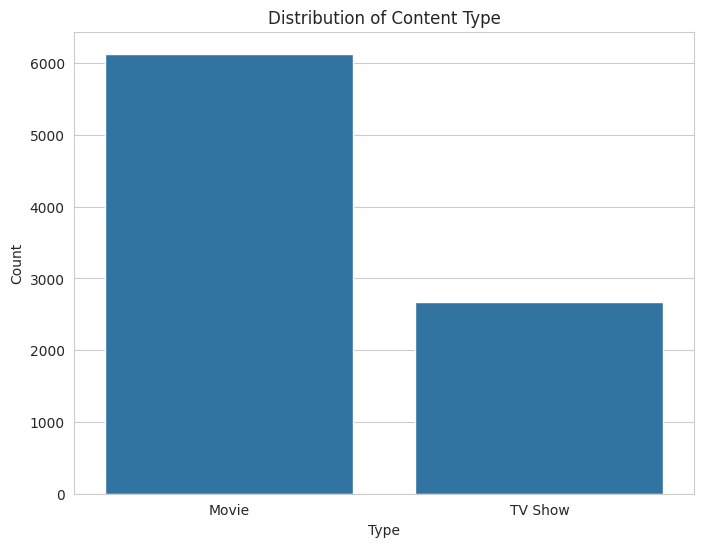

In [ ]:
# Content Type Distibution
sns.set_style('whitegrid')
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='type')
plt.title('Distribution of Content Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

Movies dominate the platform compared to tv shows
Netflix appear to prioritize movie content for scale

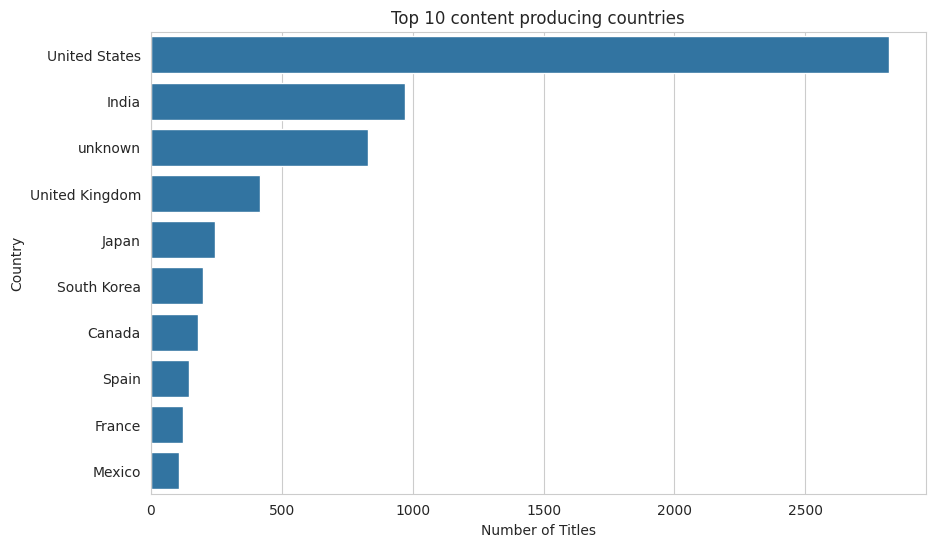

In [ ]:
#top 10 countries
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title('Top 10 content producing countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

#a few countries dominate content production
#indicates strong regional concentration of content supply

In [ ]:
#Release Year Distribution
plt.figure(figsize=12,6)

sns.histplot(df['release_year'], bins=30, kde=True)
plt.title('Release Year Distribution')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.show()

Most content is recent which suggests modern and relevant content

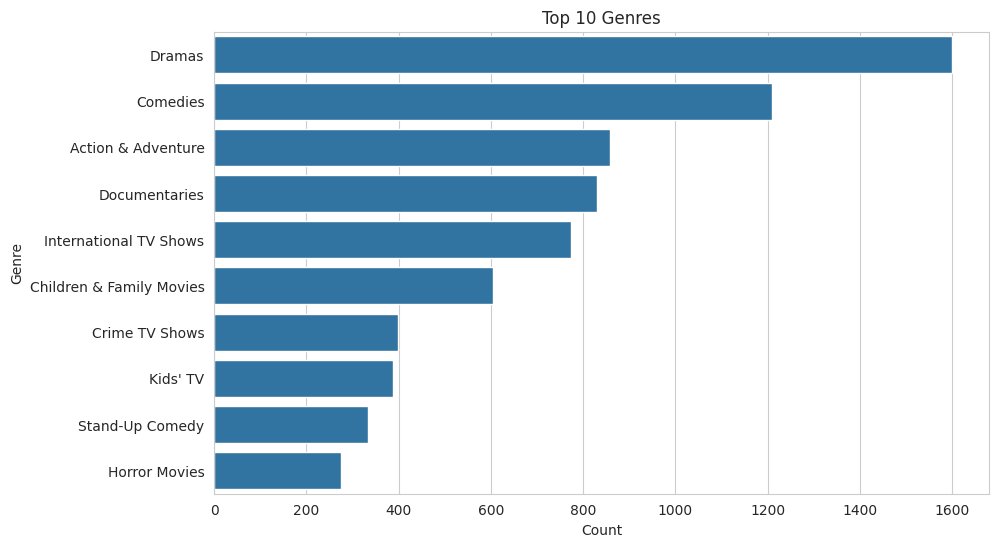

In [ ]:
#Top Genres
top_genres = df['main_genre'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title('Top 10 Genres')
plt.xlabel('Count')
plt.ylabel('Genre')

plt.show()

Certain genres like comedies and drama dominate- Showing content strategy is likely focused on mass

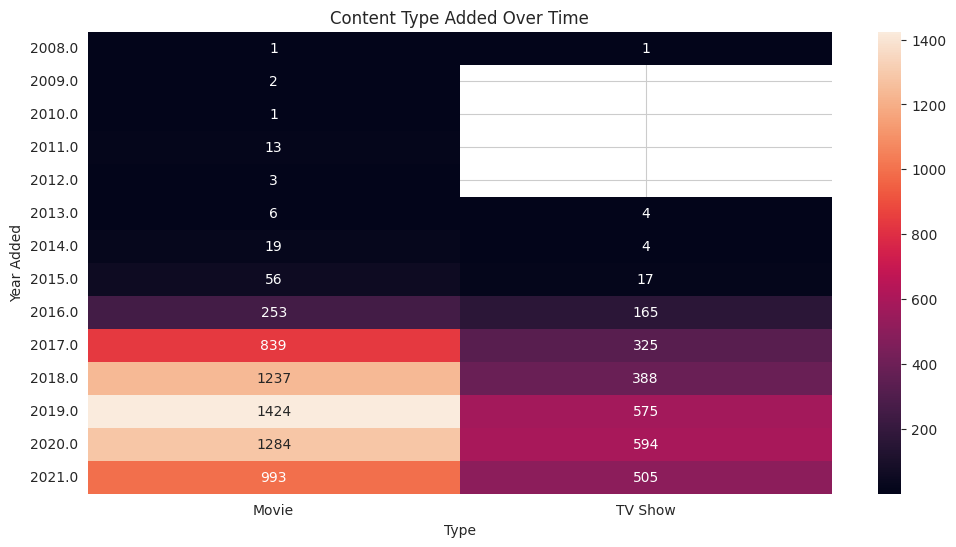

In [ ]:
#Heatmap (Year and Type)
pivot = df.pivot_table(index='year_added', columns='type', aggfunc='size')

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot = True, fmt='g')

plt.title('Content Type Added Over Time')
plt.xlabel('Type')
plt.ylabel('Year Added')
plt.show()

Growth in both Movies and TV Shows over time
Some years show spikes in specific content types

#Key Takeaways
Netflix heavily favors movies over TV shows, likely due to scalability.
Content production is dominated by a few countries, indicating regional imbalance.
There is a strong bias toward recent content, aligning with viewer demand.
Certain genres consistently dominate, suggesting a data-driven content strategy.
Rapid growth in content additions reflects platform expansion and competition strategy.